In [10]:
!pip install yfinance scikit-learn pandas matplotlib

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Fetch historical data
stock_symbol = "AAPL"
print(f"Downloading data for {stock_symbol}...")
data = yf.download(stock_symbol, start="2022-01-01", end="2026-01-01")

# Display the first few rows to verify
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,178.103638,178.954976,173.895938,174.013357,104487900
2022-01-04,175.843216,179.013683,175.275662,178.710339,99310400
2022-01-05,171.165833,176.303156,170.891843,175.755177,94537600
2022-01-06,168.308517,171.537695,167.956243,168.993491,96904000
2022-01-07,168.474854,170.402574,167.359321,169.179402,86709100


In [6]:
# Create a new column 'Next_Close' which is the 'Close' price of the next day
data['Next_Close'] = data['Close'].shift(-1)

# Drop the last row because it won't have a 'Next_Close' value
data = data.dropna()

# Select Features (X) and Target (y)
# We use Open, High, Low, Close, and Volume as our inputs
X = data[['Open', 'High', 'Low', 'Close', 'Volume']]
y = data['Next_Close']

print("Features and Target prepared.")
print(f"Total samples: {len(X)}")

Features and Target prepared.
Total samples: 1002


In [7]:
# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [8]:
# Make predictions on the test set
predictions = model.predict(X_test)

# Calculate Errors
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")

Mean Absolute Error (MAE): $2.45
Root Mean Squared Error (RMSE): $3.58


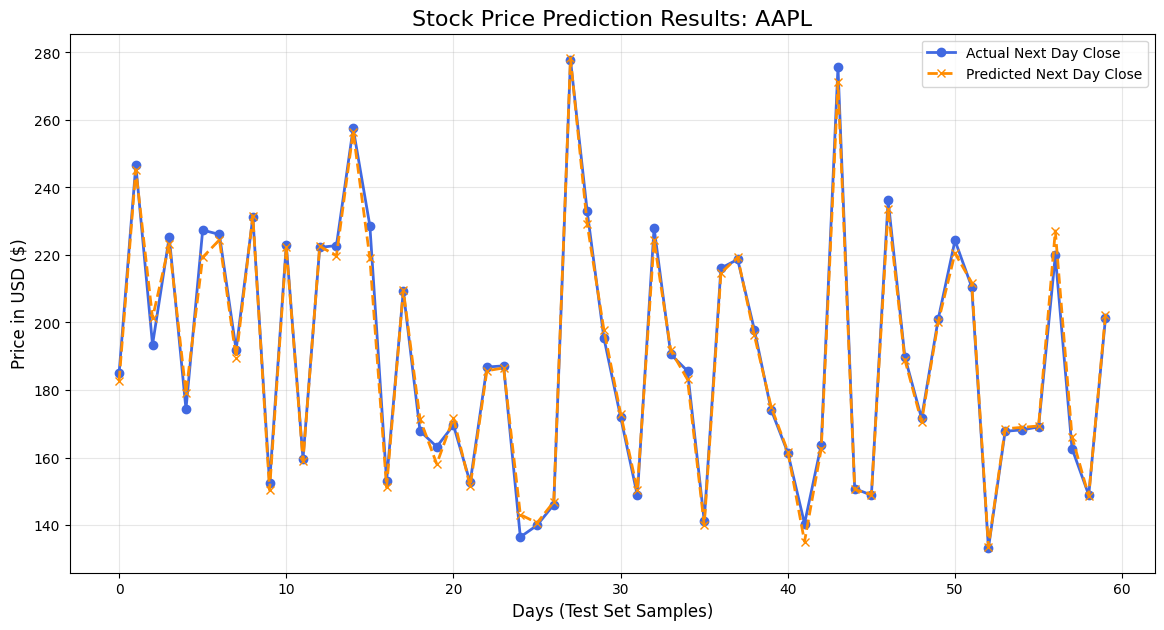

In [9]:
plt.figure(figsize=(14, 7))

# Plotting the first 60 days of the test set for clarity
plt.plot(y_test.values[:60], label="Actual Next Day Close", color='royalblue', linewidth=2, marker='o')
plt.plot(predictions[:60], label="Predicted Next Day Close", color='darkorange', linestyle='--', linewidth=2, marker='x')

plt.title(f"Stock Price Prediction Results: {stock_symbol}", fontsize=16)
plt.xlabel("Days (Test Set Samples)", fontsize=12)
plt.ylabel("Price in USD ($)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()